In [20]:
#TRACKED PARCEL STATISTICS
#MAINLY HISTOGRAMS OF CI LOCATION (T,Z)

In [3]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
# res='1km'
# Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [4]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [5]:
# # Reading Back Data Later #(IMPLEMENTED WITH H5PY WITHIN CODE BELOW)
# ##############
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'
# with h5py.File(in_file, 'r') as f:
#     Z = f['Z'][:]
#     Y = f['Y'][:]
#     X = f['X'][:]

# # #Making Time Matrix
# # rows, cols = A.shape[0], A.shape[1]
# # T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [6]:
################################################################################

In [8]:
def find_SBZ_xmaxs():
    # Define the directory and file path
    dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}_{t_res}' + '.h5'
    
    # Open the HDF5 file in read mode
    with h5py.File(file_path, 'r') as f:
        # Access the 'conv' dataset
        conv_dataset = f['conv']
        
        # Define the vertical level you are interested in
        zlev = 4
        
        # Initialize a list to store the xmaxs for each time step
        xmaxs_list = []

        # Loop over each time step (axis=0 corresponds to time)
        for t in range(conv_dataset.shape[0]):  # conv_dataset.shape[0] is the time dimension size
            # Read the relevant slice for this time step and vertical level
            Conv_t_zlev = conv_dataset[t, zlev, :, :]  # Shape should be (y_size, x_size)
            
            # Calculate the mean across the y-axis
            Conv_ymean = np.mean(Conv_t_zlev, axis=0)  # Mean across the y-axis
            
            # Find the index of the maximum value along the x-axis
            xmax = np.argmax(Conv_ymean)
            
            # Append the result for this time step
            xmaxs_list.append(xmax)
    
    # Convert the list of xmaxs to a numpy array (optional)
    xmaxs = np.array(xmaxs_list)

    return xmaxs #returns SBZ x location for each timestep

SBZ_xmaxs=find_SBZ_xmaxs()

In [ ]:
########################
#READING BACK IN
def LoadFinalData(in_file):
    dict = {}
    with h5py.File(in_file, 'r') as f:
        for key in f.keys():
            dict[key] = f[key][:]
    return dict

def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
in_file=dir2+f"parcel_tracking_SUBSET_{res}_{t_res}_{Np_str}"
final_dict=LoadFinalData(in_file)


#DYNAMICALLY CREATING VARIABLES
for key, value in final_dict.items():
    globals()[key] = value

# #DYNAMICALLY PRINTING VARIABLE SIZES
# for key in final_dict:
#     print(f"{key} has {final_dict[key].shape[0]} parcels")

# PRINTING VARIABLE SIZES (ONE BY ONE)
print(f'ALL: {len(CL_ALL_out_arr)} CL parcels and {len(nonCL_ALL_out_arr)} nonCL parcels')
print(f'SHALLOW: {len(CL_SHALLOW_out_arr)} CL parcels and {len(nonCL_SHALLOW_out_arr)} nonCL parcels')
print(f'DEEP: {len(CL_DEEP_out_arr)} CL parcels and {len(nonCL_DEEP_out_arr)} nonCL parcels')
print('\n')
print(f'ALL: {len(SBZ_ALL_out_arr)} SBZ parcels and {len(nonSBZ_ALL_out_arr)} nonSBZ parcels')
print(f'SHALLOW: {len(SBZ_SHALLOW_out_arr)} SBZ parcels and {len(nonSBZ_SHALLOW_out_arr)} nonSBZ parcels')
print(f'DEEP: {len(SBZ_DEEP_out_arr)} SBZ parcels and {len(nonSBZ_DEEP_out_arr)} nonSBZ parcels')
print('\n')
print(f'ALL: {len(ColdPool_ALL_out_arr)} ColdPool parcels')
print(f'SHALLOW: {len(ColdPool_SHALLOW_out_arr)} ColdPool parcels')
print(f'DEEP: {len(ColdPool_DEEP_out_arr)} ColdPool parcels')


#APPLYING JOB ARRAY
if "job_array" in globals():
    print('APPLYING JOB ARRAY')
    def job_filter(arr):
        return arr[(arr[:,0]>=start_job)&(arr[:,0]<end_job)]
    for name in [
        'CL_ALL_out_arr', 'CL_ALL_out_arr',
        'CL_SHALLOW_out_arr', 'CL_SHALLOW_out_arr',
        'CL_DEEP_out_arr', 'nonCL_DEEP_out_arr',
        'SBZ_ALL_out_arr', 'nonSBZ_ALL_out_arr',
        'SBZ_SHALLOW_out_arr', 'nonSBZ_SHALLOW_out_arr',
        'SBZ_DEEP_out_arr', 'nonSBZ_DEEP_out_arr',
        'ColdPool_ALL_out_arr', 'ColdPool_SHALLOW_out_arr', 'ColdPool_DEEP_out_arr'
    ]:
        globals()[name] = job_filter(globals()[name])

In [9]:
#PLOTTING
###############################

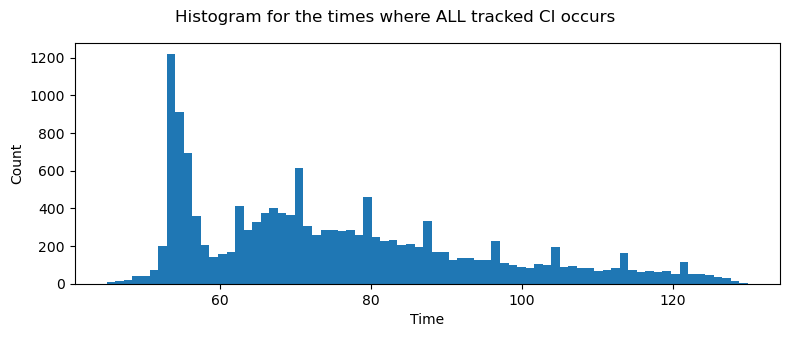

In [11]:
Ps=ALL_out_arr[:,0]
Ts=ALL_out_arr[:,1]

Time_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
for (t,p) in zip(*Position):
    Time_Lst.append(t)


########################################

num_bins=100
num_bins=75

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(Time_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time')

# 50*5/60 ==> 1000 LT
# 70*5/60 ==> 1200 LT

plt.suptitle('Histogram for the times where ALL tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap

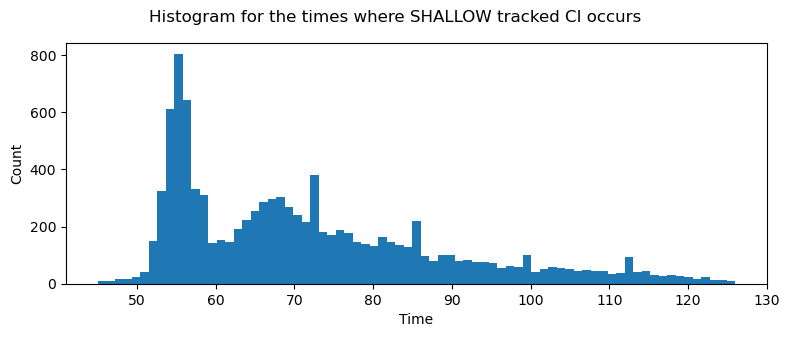

In [14]:
Ps=SHALLOW_out_arr[:,0]
Ts=SHALLOW_out_arr[:,1]

Time_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
for (t,p) in zip(*Position):
    Time_Lst.append(t)

#############################

num_bins=100
num_bins=75

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(Time_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time')

# 55*5/60 ==> 1030 LT
# 70*5/60 ==> 1200 LT

plt.suptitle('Histogram for the times where SHALLOW tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap

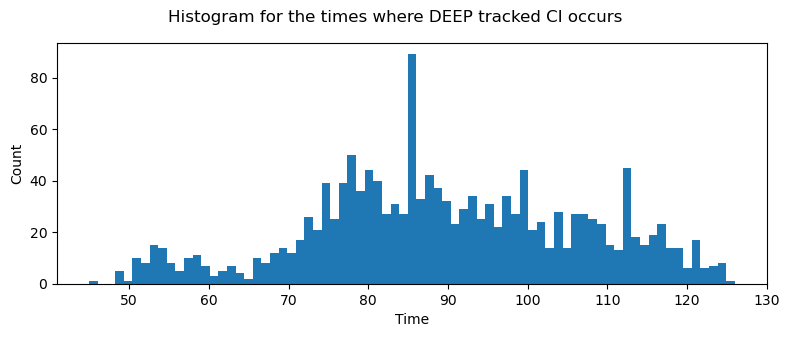

In [15]:
Ps=DEEP_out_arr[:,0]
Ts=DEEP_out_arr[:,1]

Time_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
for (t,p) in zip(*Position):
    Time_Lst.append(t)


##################################

num_bins=100
num_bins=75

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(Time_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time')

# 80*5/60 ==> 1230 LT
# 90*5/60 ==> 1330 LT

plt.suptitle('Histogram for the times where DEEP tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap

In [ ]:
#RUNNING
###############################

In [7]:
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'

########################################################################

Ps=ALL_out_arr[:,0]
Ts=ALL_out_arr[:,1]

Coast_x=int(len(data['xh'])*2/8)
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)

with h5py.File(in_file, 'r') as f:
    for count,(t,p) in enumerate(zip(*Position)):
        if np.mod(count,3000)==0: print(f"{count}/{len(Position[0])}")
        Coast_Dist=f['X'][t,p]-Coast_x
        Coast_Dist*=kms
        Coast_Lst.append(Coast_Dist)
        
        SBZ_Dist=f['X'][t,p]-SBZ_xmaxs[t]
        SBZ_Dist*=kms
        SBZ_Lst.append(SBZ_Dist)

# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

0/14941
3000/14941
6000/14941
9000/14941
12000/14941


In [41]:
#SAVING
dir3=dir+'Project_Algorithms/Tracked_Profiles/'
out_file=dir3+'ALL_Tracked_Parcel_Stats_Lists_5min.pkl'
with open(out_file, 'wb') as f:
    pickle.dump({'SBZ_Lst': SBZ_Lst, 'Coast_Lst': Coast_Lst}, f)

In [ ]:
#PLOTTING
###############################

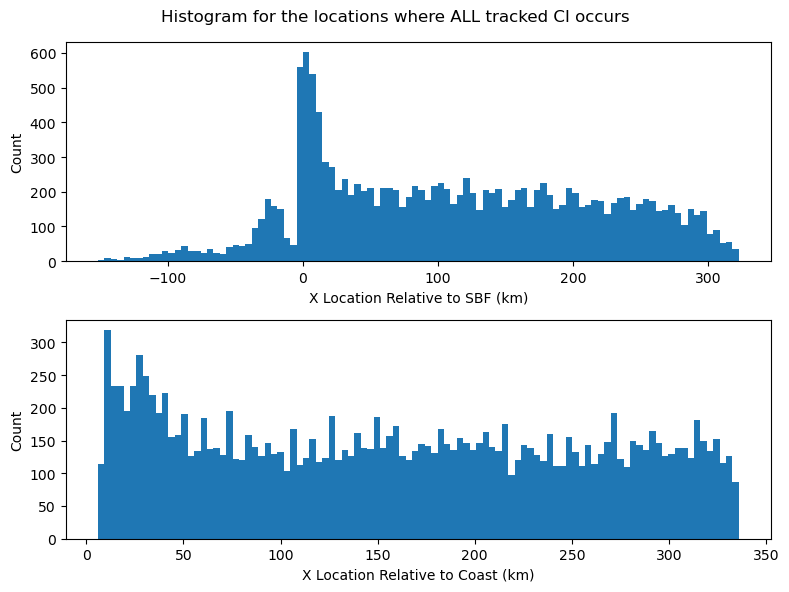

In [16]:
#READING BACK IN
dir3=dir+'Project_Algorithms/Tracked_Profiles/'
in_file=dir3+'ALL_Tracked_Parcel_Stats_Lists_5min.pkl'
with open(in_file, 'rb') as f:
    load_data = pickle.load(f)
    SBZ_Lst = load_data['SBZ_Lst']
    Coast_Lst = load_data['Coast_Lst']

#############################

num_bins=100
# num_bins=10

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(SBZ_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('X Location Relative to SBF (km)')

# Second subplot: Distance from Coast
ax2 = plt.subplot(gs[1])
ax2.hist(Coast_Lst, bins=num_bins)
ax2.set_ylabel('Count')
ax2.set_xlabel('X Location Relative to Coast (km)')


plt.suptitle('Histogram for the locations where ALL tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap



In [ ]:
#RUNNING
#############################

In [21]:
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'

####################################################################################

Ps=SHALLOW_out_arr[:,0]
Ts=SHALLOW_out_arr[:,1]

Coast_x=int(len(data['xh'])*2/8)
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
with h5py.File(in_file, 'r') as f:
    for count,(t,p) in enumerate(zip(*Position)):
        if np.mod(count,3000)==0: print(f"{count}/{len(Position[0])}")
        Coast_Dist=f['X'][t,p]-Coast_x
        Coast_Dist*=kms
        Coast_Lst.append(Coast_Dist)
        
        SBZ_Dist=f['X'][t,p]-SBZ_xmaxs[t]
        SBZ_Dist*=kms
        SBZ_Lst.append(SBZ_Dist)

# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

0/10267
3000/10267
6000/10267
9000/10267


In [ ]:
#SAVING
dir3=dir+'Project_Algorithms/Tracked_Profiles/'
out_file=dir3+'SHALLOW_Tracked_Parcel_Stats_Lists_5min.pkl'
with open(out_file, 'wb') as f:
    pickle.dump({'SBZ_Lst': SBZ_Lst, 'Coast_Lst': Coast_Lst}, f)

In [ ]:
#PLOTTING
###############################

In [ ]:
#READING BACK IN
dir3=dir+'Project_Algorithms/Tracked_Profiles/'
in_file=dir3+'SHALLOW_Tracked_Parcel_Stats_Lists_5min.pkl'
with open(in_file, 'rb') as f:
    load_data = pickle.load(f)
    SBZ_Lst = load_data['SBZ_Lst']
    Coast_Lst = load_data['Coast_Lst']

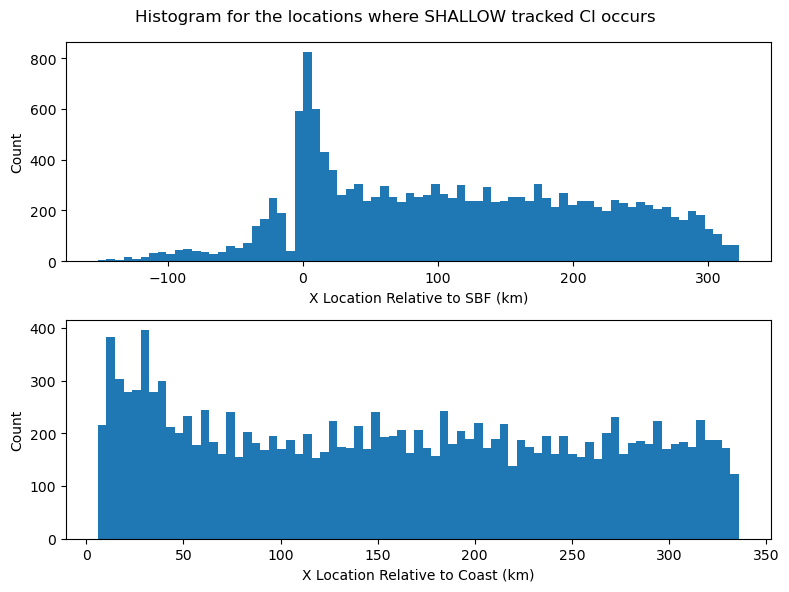

In [22]:
num_bins=100
num_bins=75

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(SBZ_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('X Location Relative to SBF (km)')

# Second subplot: Distance from Coast
ax2 = plt.subplot(gs[1])
ax2.hist(Coast_Lst, bins=num_bins)
ax2.set_ylabel('Count')
ax2.set_xlabel('X Location Relative to Coast (km)')


plt.suptitle('Histogram for the locations where SHALLOW tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap



In [ ]:
#RUNNING
#############################

In [22]:
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'

####################################################################################

Ps=DEEP_out_arr[:,0]
Ts=DEEP_out_arr[:,1]

Coast_x=int(len(data['xh'])*2/8)
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
with h5py.File(in_file, 'r') as f:
    for count,(t,p) in enumerate(zip(*Position)):
        if np.mod(count,3000)==0: print(f"{count}/{len(Position[0])}")
        Coast_Dist=f['X'][t,p]-Coast_x
        Coast_Dist*=kms
        Coast_Lst.append(Coast_Dist)
        
        SBZ_Dist=f['X'][t,p]-SBZ_xmaxs[t]
        SBZ_Dist*=kms
        SBZ_Lst.append(SBZ_Dist)

# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

0/1520


In [23]:
#SAVING
dir3=dir+'Project_Algorithms/Tracked_Profiles/'
out_file=dir3+'DEEP_Tracked_Parcel_Stats_Lists_5min.pkl'
with open(out_file, 'wb') as f:
    pickle.dump({'SBZ_Lst': SBZ_Lst, 'Coast_Lst': Coast_Lst}, f)

In [ ]:
#PLOTTING
###############################

In [24]:
#READING BACK IN
dir3=dir+'Project_Algorithms/Tracked_Profiles/'
in_file=dir3+'DEEP_Tracked_Parcel_Stats_Lists_5min.pkl'
with open(in_file, 'rb') as f:
    load_data = pickle.load(f)
    SBZ_Lst = load_data['SBZ_Lst']
    Coast_Lst = load_data['Coast_Lst']

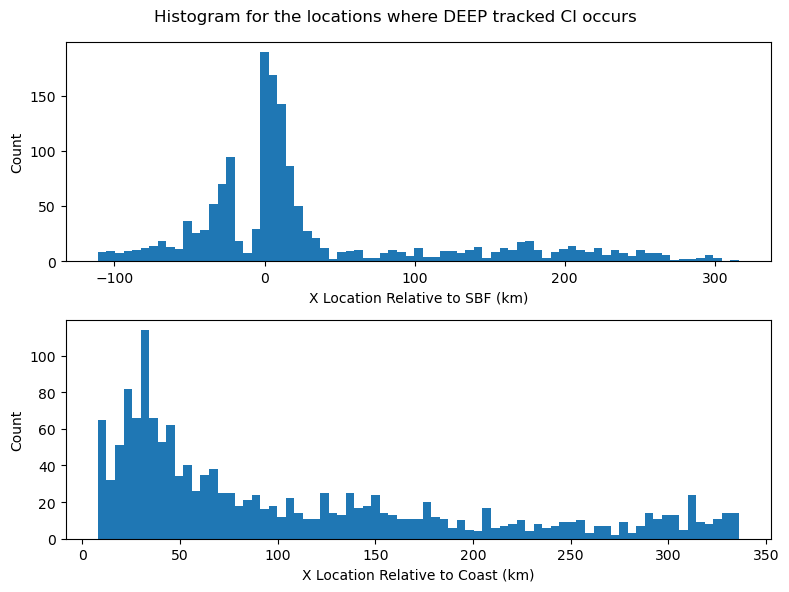

In [25]:
num_bins=100
num_bins=75

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(SBZ_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('X Location Relative to SBF (km)')

# Second subplot: Distance from Coast
ax2 = plt.subplot(gs[1])
ax2.hist(Coast_Lst, bins=num_bins)
ax2.set_ylabel('Count')
ax2.set_xlabel('X Location Relative to Coast (km)')


plt.suptitle('Histogram for the locations where DEEP tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap



In [21]:
#RUNNING
####################################################
#WHEN TRACKED PARCELS EXIT CLOUDY REGION

In [32]:
#GET AFTER ARRAYS
ALL_out_after_array=ALL_out_arr[:,3]
SHALLOW_out_after_array=SHALLOW_out_arr[:,3]
DEEP_out_after_array=DEEP_out_arr[:,3]


#AFTER TIME NEEDS TO BE ADDED TO FINAL TIMESTEPS IN OUT_ARR
ALL_out_after_array+=(ALL_out_arr[:,2]+1-ALL_out_arr[:,1]).astype(int)
SHALLOW_out_after_array+=(SHALLOW_out_arr[:,2]+1-SHALLOW_out_arr[:,1]).astype(int)
DEEP_out_after_array+=(DEEP_out_arr[:,2]+1-DEEP_out_arr[:,1]).astype(int)

In [43]:
#SAVING
dir3=dir+'Project_Algorithms/Tracked_Profiles/'
out_file=dir3+'After_Arrays_5min.npz'
np.savez(out_file,
         ALL=ALL_out_after_array,
         SHALLOW=SHALLOW_out_after_array,
         DEEP=DEEP_out_after_array)

In [ ]:
#PLOTTING
###############################################

In [44]:
dir3=dir+'Project_Algorithms/Tracked_Profiles/'
in_file=dir3+'After_Arrays_5min.npz'
load_data = np.load(in_file)
ALL_out_after_array = load_data['ALL']
SHALLOW_out_after_array = load_data['SHALLOW']
DEEP_out_after_array = load_data['DEEP']

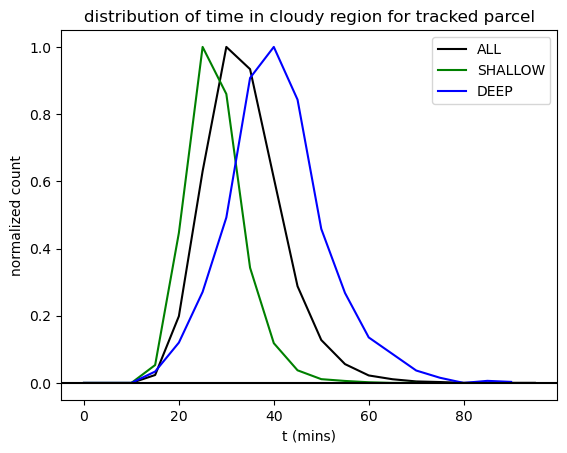

In [45]:
def get_dist(array):
    max_ind=np.max(array)+1
    profile=np.zeros((max_ind,2));profile[:,1]=np.arange(max_ind)
    
    for t in np.arange(max_ind):
        profile[t,0]+=len(array[array==t])
    return profile

arrays=[ALL_out_after_array,SHALLOW_out_after_array,DEEP_out_after_array]
labels=['ALL','SHALLOW','DEEP']
colors=['black','green','blue']


ALL_profile=get_dist(arrays[0])
SHALLOW_profile=get_dist(arrays[1])
DEEP_profile=get_dist(arrays[2])

profiles=[ALL_profile,SHALLOW_profile,DEEP_profile]


for (profile,label,color) in zip(profiles,labels,colors):
    profile[:, 0] /= np.max(profile[:, 0])
    plt.plot(profile[:,1]*5,profile[:,0],label=label,color=color)
    plt.ylabel('normalized count');plt.xlabel('t (mins)')
    plt.title('distribution of time in cloudy region for tracked parcel')
plt.legend()
plt.axhline(0,color='black')

In [ ]:
#######################################
#in the future, it might be interesting to show distance from CL for Any CL, SBZ and ColdPool
#may not be necessary though